# Import statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.svm import SVR

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [5]:
from platform import python_version

print(python_version())



3.10.12


In [4]:
!which python3

/usr/bin/python3


In [8]:
print(np.__version__)

1.26.3


# Load dataset

In [7]:
tt_set = pd.read_pickle("training_data_md.pkl")

In [8]:
tt_set.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2015,s100,0,0,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019_HeNan_2015,s1019,0,0,0,0,0,0,0,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [9]:
tt_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 251242 entries, Line to MD
dtypes: float64(5), int64(251236), object(1)
memory usage: 4.6+ GB


In [11]:
#Final_data= Final_data.drop(['new_line'], axis=1)
tt_set.set_index('Line', inplace=True)
tt_set.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,0,0,0,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014,0,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019,0,0,0,0,0,0,0,0,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [17]:
snps = Final_data.iloc[:, 0:251229]
snps.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52246739,Chr20_52247340,Chr20_52249163,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897,Chr20_52270629
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,2,2,0,2,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,2,2,0,2,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s101,0,0,1,0,0,1,1,0,0,0,...,0,1,0,0,2,2,0,2,0,0


In [18]:
prt = Final_data.iloc[:, 251237:]
prt.head()

,PRT
Line,
s100,340.553
s100,358.104
s1014,366.116
s1014,326.667
s101,385.915


In [14]:
full_pheno = tt_set.iloc[:, 251229:]
full_pheno.head()

,LL,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,
s100,9.5000,6.26667,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,10.2133,4.00000,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014,11.8200,7.78667,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,13.2800,6.94667,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019,10.8400,7.34667,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [32]:
snps_loc= Final_data.drop(['BBD', 'LL',	'LW', 'MD',	'PLH', 'PRT'], axis=1)
snps_loc.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897,Chr20_52270629,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,2,0,2,0,0,1,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,2,0,2,0,0,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,1,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,0
s101,0,0,1,0,0,1,1,0,0,0,...,0,2,2,0,2,0,0,0,0,1


In [33]:
snps_all= Final_data.drop(['MD', 'PRT'], axis=1)
snps_all.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52267177,Chr20_52267897,Chr20_52270629,BBD,LL,LW,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,2,0,0,61.0,9.5000,6.26667,154.700,1,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,2,0,0,37.0,10.2200,7.19333,130.000,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,77.0,10.3667,7.76667,111.733,1,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,42.0,11.8200,7.78667,73.000,0,1,0
s101,0,0,1,0,0,1,1,0,0,0,...,2,0,0,62.0,14.2800,10.22000,95.700,0,0,1


In [ ]:
# Split training set into training and validation

In [52]:
X_train, X_test, y_train, y_test = train_test_split(snps, prt, test_size=0.2, random_state=42)

In [142]:
xgbreg = xgb.XGBRegressor(n_jobs =-1 , gamma= 1.0, learning_rate = 0.1, max_depth=7, n_estimators= 200)

In [143]:
xgbreg.fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=1.0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=-1,
             num_parallel_tree=None, random_state=None, ...)

In [144]:
y_pred_xgboost = xgbreg.predict(X_test)

In [145]:
r2_score(y_test, y_pred_xgboost)

-0.15247130393981934

In [146]:
mse = mean_squared_error(y_test, y_pred_xgboost)

In [147]:
rmse = np.sqrt(mse)
print(rmse)

26.116685046019313


# Define all functions

In [7]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}
 

In [8]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [9]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [10]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [11]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [25]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting (no artificial filters)
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [13]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# GWAS dataset

In [15]:
#Load file
genotype = pd.read_csv('../gwas_md/top_1percent_snps.012', sep='\t', header=None)
genotype.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Columns: 2513 entries, 0 to 2512
dtypes: int64(2513)
memory usage: 24.4 MB


In [16]:
genotype.head()

,0,1,2,3,4,5,6,7,8,9,...,2503,2504,2505,2506,2507,2508,2509,2510,2511,2512
0,0,2,1,0,0,0,2,0,1,0,...,0,0,2,0,0,2,2,0,0,0
1,1,0,2,2,0,0,2,0,0,2,...,0,0,0,2,1,0,2,0,0,0
2,2,1,1,1,2,1,0,0,0,0,...,0,0,2,0,0,0,0,2,0,0
3,3,1,1,0,0,1,0,1,0,2,...,0,0,0,2,0,0,0,0,2,1
4,4,1,0,2,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [17]:
genotype.set_index(genotype.columns[0], inplace =True)
genotype.head()

,1,2,3,4,5,6,7,8,9,10,...,2503,2504,2505,2506,2507,2508,2509,2510,2511,2512
0,,,,,,,,,,,,,,,,,,,,,
0,2,1,0,0,0,2,0,1,0,2,...,0,0,2,0,0,2,2,0,0,0
1,0,2,2,0,0,2,0,0,2,2,...,0,0,0,2,1,0,2,0,0,0
2,1,1,1,2,1,0,0,0,0,2,...,0,0,2,0,0,0,0,2,0,0
3,1,1,0,0,1,0,1,0,2,2,...,0,0,0,2,0,0,0,0,2,1
4,1,0,2,0,0,0,0,0,0,2,...,0,0,0,1,0,0,0,0,0,0


In [18]:
column_names = pd.read_csv('../gwas_md/id_names_top1.txt', sep=' ', header=None)

In [19]:
column_names.head

<bound method NDFrame.head of                    0
0        Chr1_123617
1        Chr1_325800
2       Chr1_1127979
3       Chr1_1454789
4       Chr1_1721307
...              ...
2507  Chr20_48584494
2508  Chr20_49775939
2509  Chr20_50059719
2510  Chr20_50927742
2511  Chr20_52247340

[2512 rows x 1 columns]>

In [20]:
genotype.columns = column_names
genotype.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1275 entries, 0 to 1274
Columns: 2512 entries, ('Chr1_123617',) to ('Chr20_52247340',)
dtypes: int64(2512)
memory usage: 24.4 MB


In [21]:
genotype.head()

,"(Chr1_123617,)","(Chr1_325800,)","(Chr1_1127979,)","(Chr1_1454789,)","(Chr1_1721307,)","(Chr1_2489311,)","(Chr1_2543095,)","(Chr1_3224401,)","(Chr1_3642923,)","(Chr1_3858802,)",...,"(Chr20_40889952,)","(Chr20_40942681,)","(Chr20_41470065,)","(Chr20_43647688,)","(Chr20_47311522,)","(Chr20_48584494,)","(Chr20_49775939,)","(Chr20_50059719,)","(Chr20_50927742,)","(Chr20_52247340,)"
0,,,,,,,,,,,,,,,,,,,,,
0,2,1,0,0,0,2,0,1,0,2,...,0,0,2,0,0,2,2,0,0,0
1,0,2,2,0,0,2,0,0,2,2,...,0,0,0,2,1,0,2,0,0,0
2,1,1,1,2,1,0,0,0,0,2,...,0,0,2,0,0,0,0,2,0,0
3,1,1,0,0,1,0,1,0,2,2,...,0,0,0,2,0,0,0,0,2,1
4,1,0,2,0,0,0,0,0,0,2,...,0,0,0,1,0,0,0,0,0,0


In [22]:
#Adding row names
rows= pd.read_csv('../gwas_md/top_1percent_indv.txt', header=None)
rows.head()

,0
0,s63
1,s64
2,s66
3,s70
4,s71


In [23]:
genotype.index = rows
genotype.head()

,"(Chr1_123617,)","(Chr1_325800,)","(Chr1_1127979,)","(Chr1_1454789,)","(Chr1_1721307,)","(Chr1_2489311,)","(Chr1_2543095,)","(Chr1_3224401,)","(Chr1_3642923,)","(Chr1_3858802,)",...,"(Chr20_40889952,)","(Chr20_40942681,)","(Chr20_41470065,)","(Chr20_43647688,)","(Chr20_47311522,)","(Chr20_48584494,)","(Chr20_49775939,)","(Chr20_50059719,)","(Chr20_50927742,)","(Chr20_52247340,)"
"(s63,)",2,1,0,0,0,2,0,1,0,2,...,0,0,2,0,0,2,2,0,0,0
"(s64,)",0,2,2,0,0,2,0,0,2,2,...,0,0,0,2,1,0,2,0,0,0
"(s66,)",1,1,1,2,1,0,0,0,0,2,...,0,0,2,0,0,0,0,2,0,0
"(s70,)",1,1,0,0,1,0,1,0,2,2,...,0,0,0,2,0,0,0,0,2,1
"(s71,)",1,0,2,0,0,0,0,0,0,2,...,0,0,0,1,0,0,0,0,0,0


In [24]:
genotype.to_csv('genotype_top1_percent_md.txt', sep ='\t', index = True)

In [27]:
!sed 's/[,()\x27]//g'  genotype_top1_percent_md.txt > genotype_top1_percent_md_new.txt

In [28]:
#Load the genotype data
genotype_new = pd.read_csv('genotype_top1_percent_md_new.txt', sep = '\t')
genotype_new.head()

,Unnamed: 0,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,...,Chr20_40889952,Chr20_40942681,Chr20_41470065,Chr20_43647688,Chr20_47311522,Chr20_48584494,Chr20_49775939,Chr20_50059719,Chr20_50927742,Chr20_52247340
0,s63,2,1,0,0,0,2,0,1,0,...,0,0,2,0,0,2,2,0,0,0
1,s64,0,2,2,0,0,2,0,0,2,...,0,0,0,2,1,0,2,0,0,0
2,s66,1,1,1,2,1,0,0,0,0,...,0,0,2,0,0,0,0,2,0,0
3,s70,1,1,0,0,1,0,1,0,2,...,0,0,0,2,0,0,0,0,2,1
4,s71,1,0,2,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [30]:
genotype_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Columns: 2513 entries, Line to Chr20_52247340
dtypes: int64(2512), object(1)
memory usage: 24.4+ MB


In [29]:
#Setting the index and naming the index column 
genotype_new = genotype_new.rename(columns={genotype_new.columns[0]: 'Line'})
genotype_new.set_index(genotype_new.columns[0])

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,Chr20_40889952,Chr20_40942681,Chr20_41470065,Chr20_43647688,Chr20_47311522,Chr20_48584494,Chr20_49775939,Chr20_50059719,Chr20_50927742,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s63,2,1,0,0,0,2,0,1,0,2,...,0,0,2,0,0,2,2,0,0,0
s64,0,2,2,0,0,2,0,0,2,2,...,0,0,0,2,1,0,2,0,0,0
s66,1,1,1,2,1,0,0,0,0,2,...,0,0,2,0,0,0,0,2,0,0
s70,1,1,0,0,1,0,1,0,2,2,...,0,0,0,2,0,0,0,0,2,1
s71,1,0,2,0,0,0,0,0,0,2,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s2894,0,1,2,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s2895,1,0,2,0,0,0,1,0,0,0,...,0,0,0,2,1,2,0,0,2,0
s2896,0,2,0,0,0,0,0,0,0,2,...,0,0,0,2,0,0,0,0,0,0


In [36]:
full_pheno.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LL                 2450 non-null   float64
 1   LW                 2450 non-null   float64
 2   PLH                2450 non-null   float64
 3   VBN                2450 non-null   float64
 4   BeiJing_2013       2450 non-null   int64  
 5   HeNan_2014         2450 non-null   int64  
 6   HeNan_2015         2450 non-null   int64  
 7   HeiLongJiang_2014  2450 non-null   int64  
 8   HeiLongJiang_2015  2450 non-null   int64  
 9   improved_cultivar  2450 non-null   int64  
 10  landrace           2450 non-null   int64  
 11  MD                 2450 non-null   float64
dtypes: float64(5), int64(7)
memory usage: 248.8+ KB


In [31]:
gwas_data = pd.merge(genotype_new, full_pheno, on='Line', how='outer', indicator=False)

In [33]:
gwas_data = gwas_data.reset_index().set_index('Line')

In [34]:
gwas_data= gwas_data.drop(['index'], axis=1)

In [35]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 2524 entries, Chr1_123617 to MD
dtypes: float64(5), int64(2519)
memory usage: 47.2+ MB


In [37]:
gwas_data.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,1,0,2,0,0,0,0,1,0,2,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s101,0,2,2,0,0,0,0,1,0,0,...,95.7,4.20000,0,0,0,1,0,0,1,149.0
s1014,0,0,0,0,1,0,1,1,0,2,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,0,0,0,1,0,1,1,0,2,...,79.0,3.40000,0,0,1,0,0,0,1,104.0


# GWAS all traits

In [7]:
#gwas_data.to_pickle("GWAS_top1percent_md_data.pkl")
gwas_data = pd.read_pickle("../pickle_files/GWAS_top1percent_md_data.pkl")
gwas_data.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,1,0,2,0,0,0,0,1,0,2,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s101,0,2,2,0,0,0,0,1,0,0,...,95.7,4.20000,0,0,0,1,0,0,1,149.0
s1014,0,0,0,0,1,0,1,1,0,2,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,0,0,0,1,0,1,1,0,2,...,79.0,3.40000,0,0,1,0,0,0,1,104.0


In [8]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 2524 entries, Chr1_123617 to MD
dtypes: float64(5), int64(2519)
memory usage: 47.2+ MB


In [9]:
gwas_y = gwas_data.iloc[:, 2523:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


In [10]:
gwas_all= gwas_data.drop(['MD'], axis=1)
gwas_all.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,0,2,0,0,0,0,1,0,2,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,10.22000,95.7,4.20000,0,0,0,1,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1


In [11]:
gwas_all_dupe= gwas_data.drop(['MD'], axis=1)
gwas_all_dupe.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,0,2,0,0,0,0,1,0,2,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,10.22000,95.7,4.20000,0,0,0,1,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1


# Run models

In [19]:
X_train, X_test, y_train, y_test = train_test_split(gwas_all, gwas_y, test_size=0.1, random_state=42)

In [20]:
X_train.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2674,1,0,0,0,0,0,0,1,0,0,...,6.55333,77.6,1.20000,0,1,0,0,0,1,0
s2862,0,1,2,0,0,0,1,0,0,2,...,5.77333,49.0,1.60000,0,0,1,0,0,1,0
s308,0,1,1,0,0,2,0,0,2,2,...,7.44000,104.0,5.00000,0,1,0,0,0,0,1
s202,0,0,2,0,0,0,0,0,0,2,...,6.00000,22.7,3.33333,1,0,0,0,0,1,0
s614,0,2,2,0,1,0,0,0,0,0,...,6.58667,86.0,3.40000,0,1,0,0,0,1,0


In [21]:
X_train = X_train.to_numpy()

In [22]:
y_train = y_train.to_numpy()

In [23]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])


In [13]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])

In [24]:
gwas_all = gwas_all.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7320099287000679
RMSE for dataset is:7.7464954240582875& mean of this fold is 114.0
this is 6.7951714246125325% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6956843746944024
RMSE for dataset is:8.366930255452742& mean of this fold is 117.13061224489796
this is 7.143248118569612% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6637427038297481
RMSE for dataset is:9.057514389828416& mean of this fold is 118.66938775510204
this is 7.632561826745415% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6557254844271915
RMSE for dataset is:8.527381599989534& mean of this fold is 116.24897959183673
this is 7.3354464098782906% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7109394933204933
RMSE for dataset is:8.49

In [36]:
pickle.dump(best_xgbr_model, open("gwas_top1_allfeats_xgbr_md.pickle.dat", "wb"))

In [27]:
best_xgbr_model = pickle.load(open("../pickle_bestmodels/gwas_top1_allfeats_xgbr_md.pickle.dat", "rb"))

<Figure size 2000x2000 with 0 Axes>

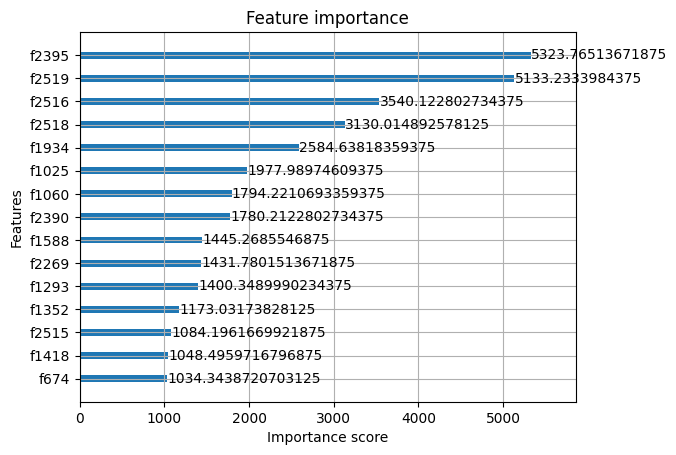

In [37]:
from xgboost import plot_importance
from matplotlib import pyplot
#best_model = pickle.load(open("Oil_kfold_10_tt_from_all.pickle.dat", "rb"))
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

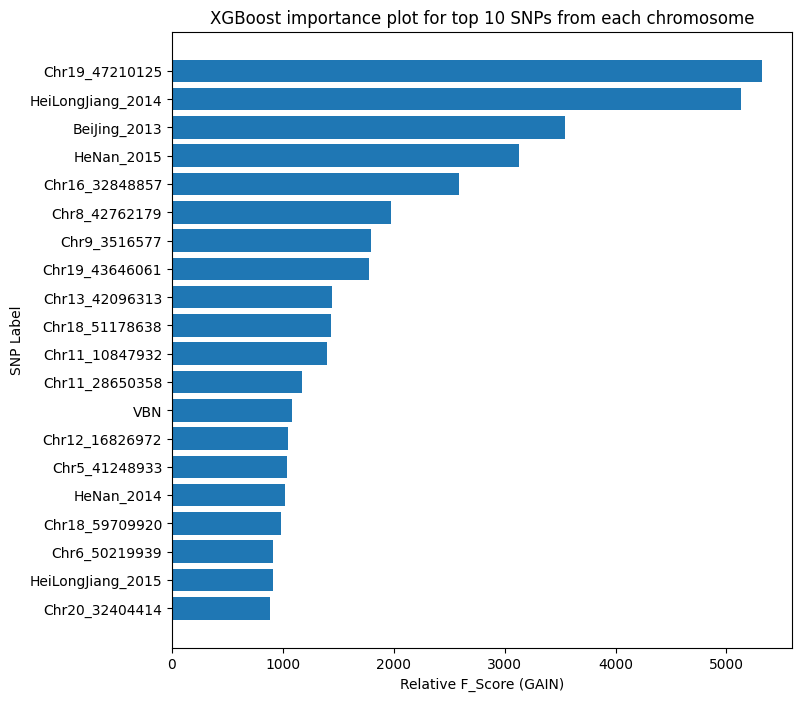

In [38]:
f_names = ['f' + str(i) for i in range(len(gwas_all_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[gwas_all_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome.png')

In [39]:
explainer = shap.Explainer(best_xgbr_model)

In [40]:
shap_values = explainer(gwas_all_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

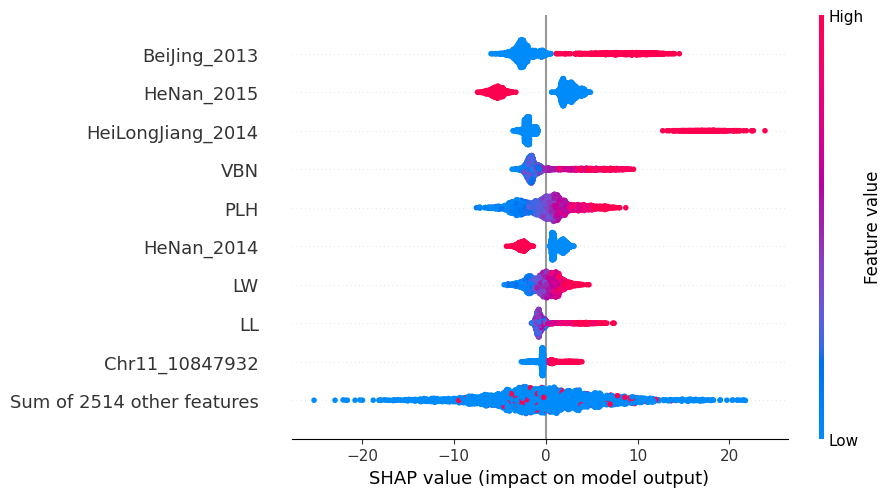

In [41]:
shap.plots.beeswarm(shap_values, show=False)

In [13]:
holdout_data = pd.read_pickle("../pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [14]:
holdout_data = holdout_data.set_index('Line')

In [15]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [16]:
holdout_data= holdout_data.drop(['index','new_line', 'MD'], axis=1)

KeyError: "['index', 'new_line'] not found in axis"

In [17]:
X_holdout = holdout_data.iloc[:, 0:251240]

In [18]:
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [19]:
y_holdout = holdout_data.iloc[:, 251240:]

In [20]:
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [21]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [22]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 2523 entries, Chr1_123617 to landrace
dtypes: float64(4), int64(2519)
memory usage: 11.8+ MB


In [23]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.76
RMSE of Holdout: 9.46
Mean of Holdout: 117.42
This is 8.06% of the mean pheno data
0 117.0 111.33207
1 148.0 146.8108
2 117.0 112.57967
3 121.0 125.0502
4 119.0 124.08017


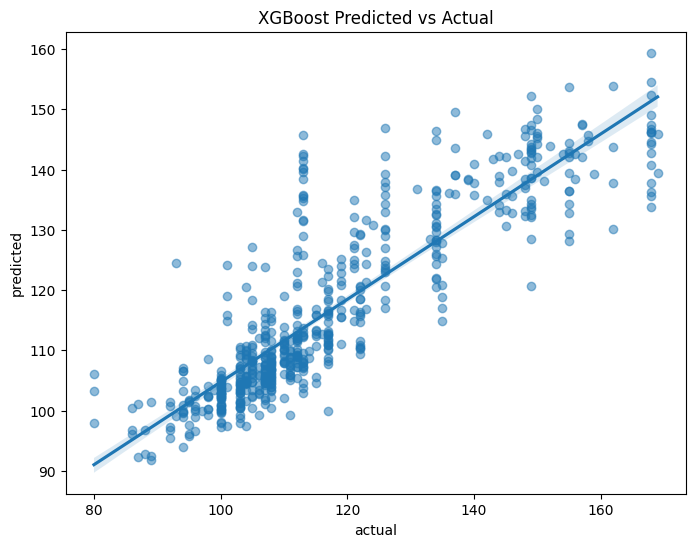

In [28]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [ ]:
#### RF models

In [42]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 34), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 17), ('n_estimators', 500)])


In [43]:
best_rfr_model = eval_k_fold(best_rfreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.009923694928394
RMSE for dataset is:14.234178917876257& mean of this fold is 115.66122448979591
this is 12.306785597909741% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.166457421038648
RMSE for dataset is:15.047319680395645& mean of this fold is 116.9
this is 12.871958665864538% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.17504890560483
RMSE for dataset is:15.319372584252747& mean of this fold is 117.89795918367346
this is 12.993755524119518% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.949242403488169
RMSE for dataset is:14.53417443862063& mean of this fold is 115.64081632653061
this is 12.568377585281851% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.0768378842229938
RMSE for dataset is:

In [44]:
pickle.dump(best_rfr_model, open("gwas_top1_allfeats_rfr_md.pickle.dat", "wb"))

In [29]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/gwas_top1_allfeats_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.35
RMSE of Holdout: 15.59
Mean of Holdout: 117.42
This is 13.27% of the mean pheno data
0 117.0 121.97524994871785
1 148.0 124.32151900228305
2 117.0 115.37807213047914
3 121.0 127.87631781655388
4 119.0 127.64666302163226


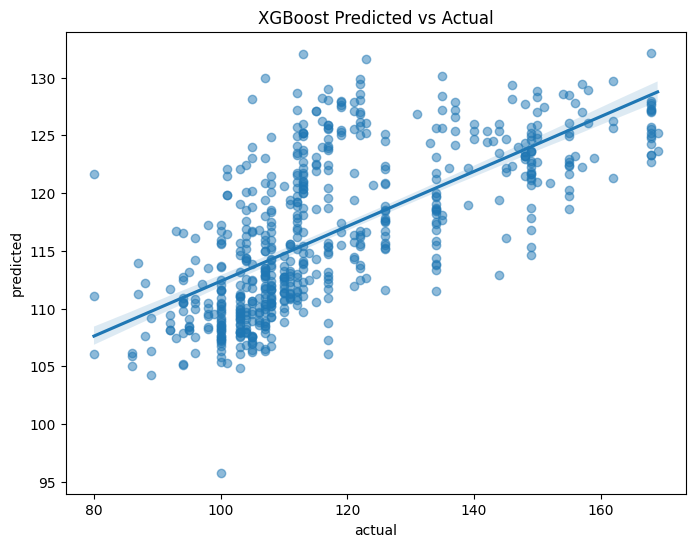

In [30]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [34]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [35]:
gwas_all = gwas_all.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.759339717100968
RMSE for dataset is:8.722793708904732& mean of this fold is 116.28571428571429
this is 7.501173951146575% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7733012050453258
RMSE for dataset is:8.939264848338173& mean of this fold is 115.97142857142858
this is 7.7081613622034% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.677026137684262
RMSE for dataset is:9.968867664329526& mean of this fold is 115.99591836734695
this is 8.594153832860881% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7502885064063888
RMSE for dataset is:9.378753378579491& mean of this fold is 116.86530612244898
this is 8.025267455127045% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7701427991216918
RMSE for dataset i

In [36]:
pickle.dump(best_svr_model, open("gwas_top1_allfeats_svr_md.pickle.dat", "wb"))

In [31]:
best_svr_model = pickle.load(open("../pickle_bestmodels/gwas_top1_allfeats_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.73
RMSE of Holdout: 10.02
Mean of Holdout: 117.42
This is 8.54% of the mean pheno data
0 117.0 120.06688057766826
1 148.0 142.40208956815206
2 117.0 117.3085618362262
3 121.0 125.0747821156516
4 119.0 125.18578228953777


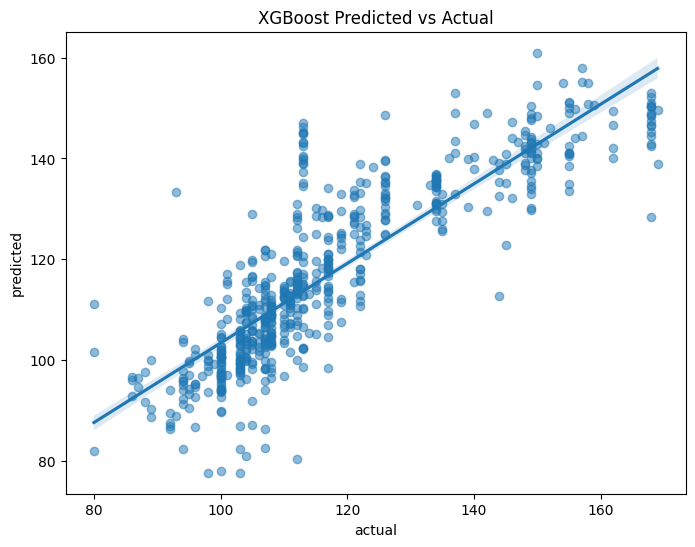

In [32]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only SNPs

In [33]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 2524 entries, Chr1_123617 to MD
dtypes: float64(5), int64(2519)
memory usage: 47.2+ MB


In [34]:
gwas_snps = gwas_data.iloc[:, 0:2512]
gwas_snps.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,Chr20_40889952,Chr20_40942681,Chr20_41470065,Chr20_43647688,Chr20_47311522,Chr20_48584494,Chr20_49775939,Chr20_50059719,Chr20_50927742,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,0,1,0,2,0,0,0,1
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,0,1,0,2,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,1,0,0,1,0,2,2,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,0,2,0,0,0,0
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,0,2,0,0,0,0


In [35]:
gwas_snps_dupe = gwas_data.iloc[:, 0:2512]
gwas_snps_dupe.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,Chr20_40889952,Chr20_40942681,Chr20_41470065,Chr20_43647688,Chr20_47311522,Chr20_48584494,Chr20_49775939,Chr20_50059719,Chr20_50927742,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,0,1,0,2,0,0,0,1
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,0,1,0,2,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,1,0,0,1,0,2,2,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,0,2,0,0,0,0
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,0,2,0,0,0,0


In [36]:
gwas_y = gwas_data.iloc[:, 2523:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


# Run models

In [42]:
X_train, X_test, y_train, y_test = train_test_split(gwas_snps, gwas_y, test_size=0.1, random_state=42)

In [43]:
X_train.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,Chr20_40889952,Chr20_40942681,Chr20_41470065,Chr20_43647688,Chr20_47311522,Chr20_48584494,Chr20_49775939,Chr20_50059719,Chr20_50927742,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s2674,1,0,0,0,0,0,0,1,0,0,...,0,0,0,2,0,2,1,0,2,0
s2862,0,1,2,0,0,0,1,0,0,2,...,1,0,0,0,0,0,0,0,0,0
s308,0,1,1,0,0,2,0,0,2,2,...,0,0,0,0,0,0,0,0,0,0
s202,0,0,2,0,0,0,0,0,0,2,...,0,0,0,1,0,2,2,0,0,0
s614,0,2,2,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [44]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [53]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.14638413202022832), ('colsample_bytree', 0.12268563166303768), ('gamma', 0.003272909619989833), ('learning_rate', 0.04299471176755962), ('max_delta_step', 13), ('max_depth', 1), ('min_child_weight', 3), ('n_estimators', 187), ('reg_alpha', 0.7519510777663355), ('reg_lambda', 1.0193603023879012e-05), ('subsample', 0.25155383002194887)])


In [54]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.14638413202022832), ('colsample_bytree', 0.12268563166303768), ('gamma', 0.003272909619989833), ('learning_rate', 0.04299471176755962), ('max_delta_step', 13), ('max_depth', 1), ('min_child_weight', 3), ('n_estimators', 187), ('reg_alpha', 0.7519510777663355), ('reg_lambda', 1.0193603023879012e-05), ('subsample', 0.25155383002194887)])

OrderedDict([('colsample_bylevel', 0.9132100359267209), ('colsample_bytree', 0.7679711803126804), ('gamma', 2.428808912219129e-07), ('learning_rate', 0.03511167856740689), ('max_delta_step', 3), ('max_depth', 8), ('min_child_weight', 4), ('n_estimators', 197), ('reg_alpha', 0.023358352781682152), ('reg_lambda', 2.1396512525873352e-07), ('scale_pos_weight', 0.001760608876847004), ('subsample', 0.15990388740095085)])


In [54]:
gwas_snps = gwas_snps.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -40.26660483814475
RMSE for dataset is:16.622903597649458& mean of this fold is 113.48979591836735
this is 14.64704686719697% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -39.03839077004734
RMSE for dataset is:18.345376481047925& mean of this fold is 116.93061224489796
this is 15.689113508296362% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -51.450717442221354
RMSE for dataset is:18.69458678117088& mean of this fold is 116.65306122448979
this is 16.025800424726615% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -39.234978941853
RMSE for dataset is:18.03878829805683& mean of this fold is 116.21224489795918
this is 15.522278494745445% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -38.335593904671306
RMSE for 

In [55]:
pickle.dump(best_xgbr_model, open("gwas_top1_onlysnps_xgbr_md.pickle.dat", "wb"))

In [37]:
best_xgbr_model = pickle.load(open("../pickle_bestmodels/gwas_top1_onlysnps_xgbr_md.pickle.dat", "rb"))

<Figure size 2000x2000 with 0 Axes>

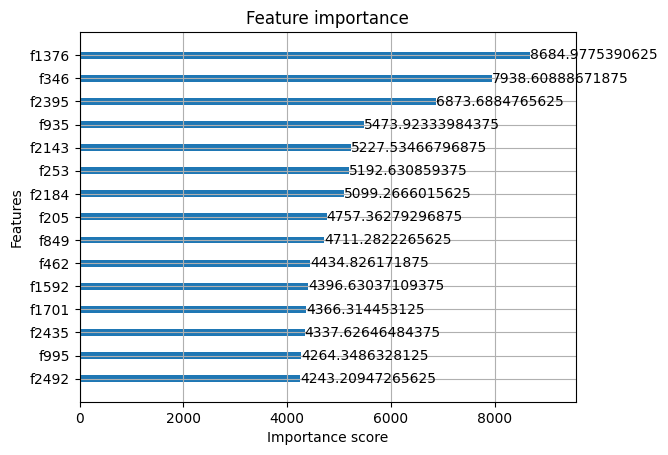

In [56]:
from xgboost import plot_importance
from matplotlib import pyplot
#best_model = pickle.load(open("Oil_kfold_10_tt_from_all.pickle.dat", "rb"))
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

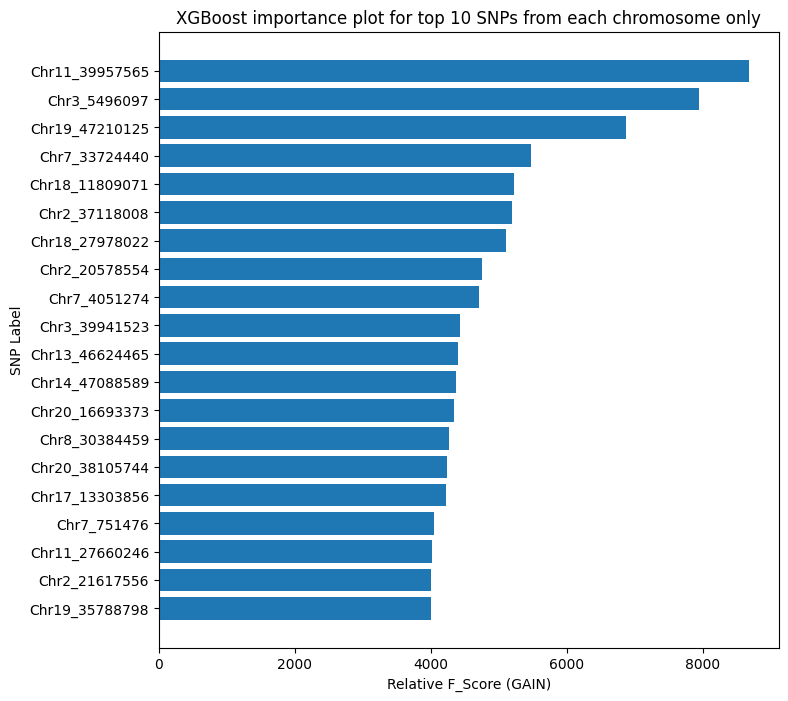

In [57]:
f_names = ['f' + str(i) for i in range(len(gwas_snps_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[gwas_snps_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome only')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome only.png')

In [58]:
explainer = shap.Explainer(best_xgbr_model)

In [59]:
shap_values = explainer(gwas_snps_dupe)

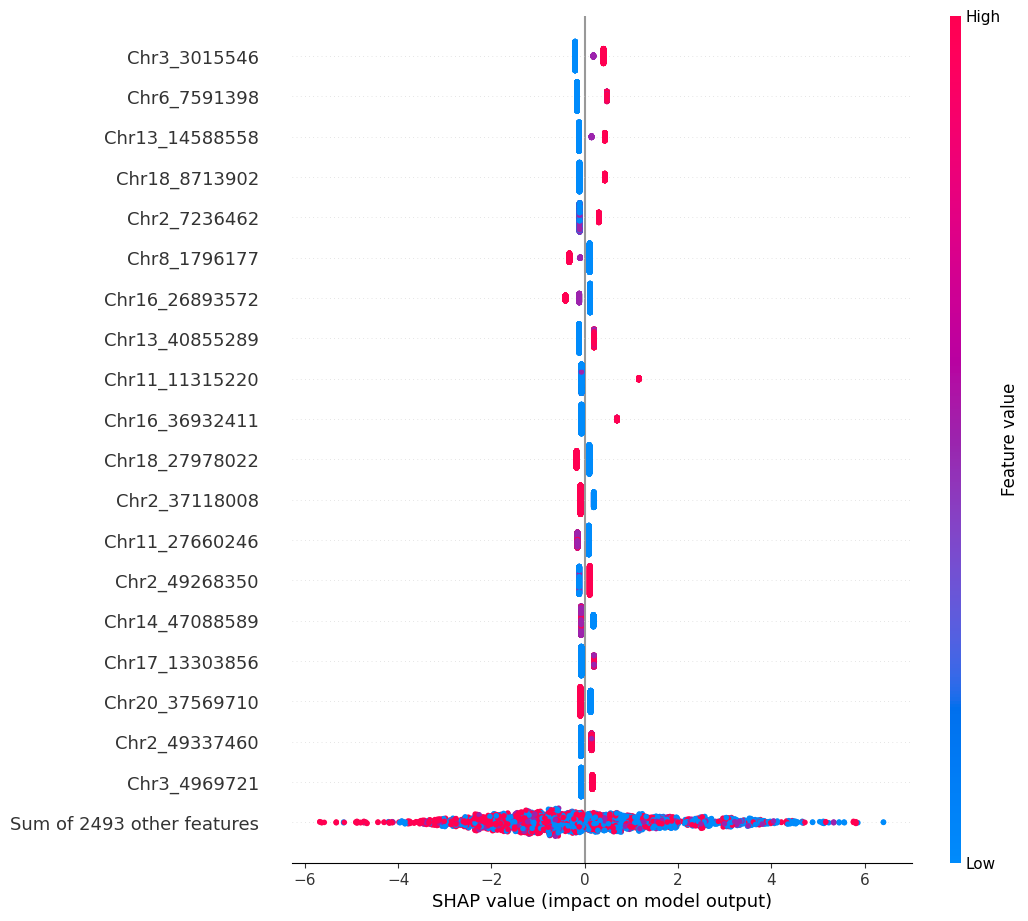

In [60]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])


In [45]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [46]:
holdout_data = holdout_data.set_index('Line')

In [47]:
holdout_data= holdout_data.drop(['new_line'], axis=1)

KeyError: "['new_line'] not found in axis"

In [38]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [39]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [40]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [41]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 2512 entries, Chr1_123617 to Chr20_52247340
dtypes: int64(2512)
memory usage: 11.8+ MB


In [42]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.03
RMSE of Holdout: 19.01
Mean of Holdout: 117.42
This is 16.19% of the mean pheno data
0 117.0 118.961586
1 148.0 117.31334
2 117.0 111.7215
3 121.0 118.16367
4 119.0 118.16367


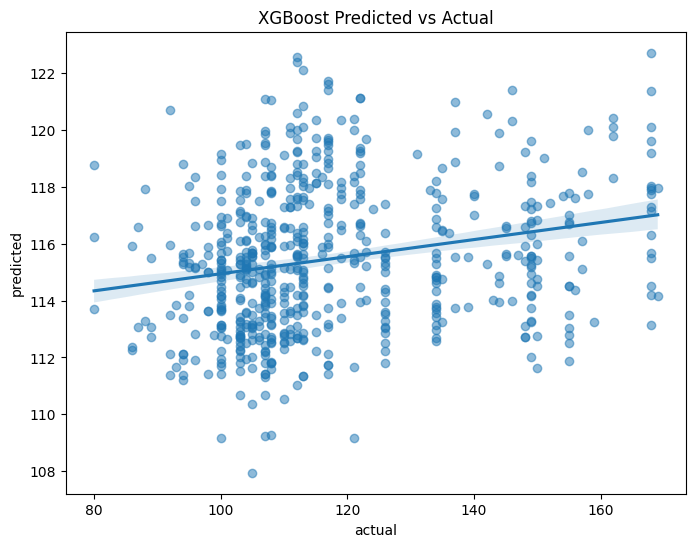

In [43]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [ ]:
#### RF models

In [69]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 8), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 11), ('n_estimators', 322)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 8), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 11), ('n_estimators', 322)])

In [73]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -41.80574260525355
RMSE for dataset is:18.4329282927358& mean of this fold is 115.98367346938775
this is 15.892692256898474% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -41.49174624829566
RMSE for dataset is:20.240973357531853& mean of this fold is 115.97551020408163
this is 17.452799579768087% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -44.88564251781839
RMSE for dataset is:18.39626754486993& mean of this fold is 115.93877551020408
this is 15.867226011241446% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -33.924447872108026
RMSE for dataset is:18.039139973513848& mean of this fold is 115.12244897959184
this is 15.669524174830324% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -46.06304851978404
RMSE for

In [74]:
pickle.dump(best_rfr_model, open("gwas_top1_onlysnps_rfr_md.pickle.dat", "wb"))

In [46]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/gwas_top1_onlysnps_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.03
RMSE of Holdout: 19.07
Mean of Holdout: 117.42
This is 16.24% of the mean pheno data
0 117.0 120.10979359156461
1 148.0 115.21140522344382
2 117.0 114.27636497616143
3 121.0 120.69594545599469
4 119.0 120.69594545599469


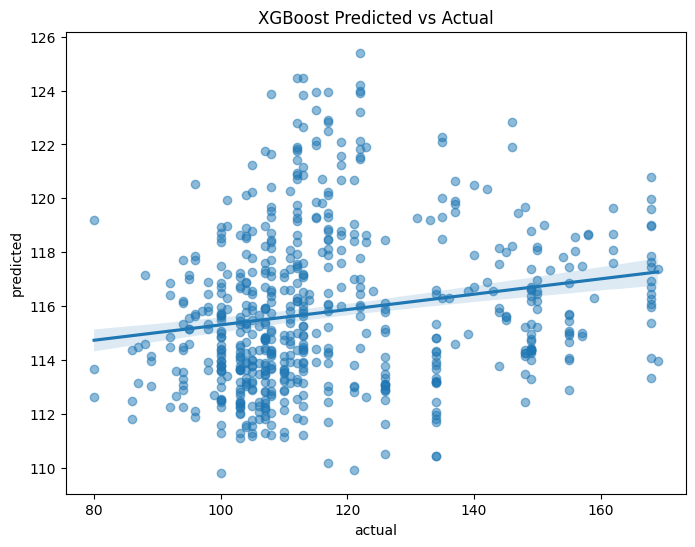

In [47]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [53]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 3), ('kernel', 'sigmoid')])


In [54]:
gwas_snps = gwas_snps.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -64.18752001066768
RMSE for dataset is:21.291414962079475& mean of this fold is 118.66122448979591
this is 17.943026505604955% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -44.80151049191298
RMSE for dataset is:19.92578590526079& mean of this fold is 116.7673469387755
this is 17.064518829659164% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -41.05341465332386
RMSE for dataset is:17.63154522484135& mean of this fold is 114.42040816326531
this is 15.409440944908253% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -47.19017863837999
RMSE for dataset is:18.980325263569533& mean of this fold is 114.95102040816326
this is 16.51166313806958% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -56.222604632867224
RMSE for 

In [55]:
pickle.dump(best_svr_model, open("gwas_top1_onlysnps_svr_md.pickle.dat", "wb"))

In [44]:
best_svr_model = pickle.load(open("../pickle_bestmodels/gwas_top1_onlysnps_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: -0.07
RMSE of Holdout: 20.01
Mean of Holdout: 117.42
This is 17.05% of the mean pheno data
0 117.0 113.21402496143298
1 148.0 111.71155802241327
2 117.0 108.78347909381785
3 121.0 114.2265962255848
4 119.0 114.2265962255848


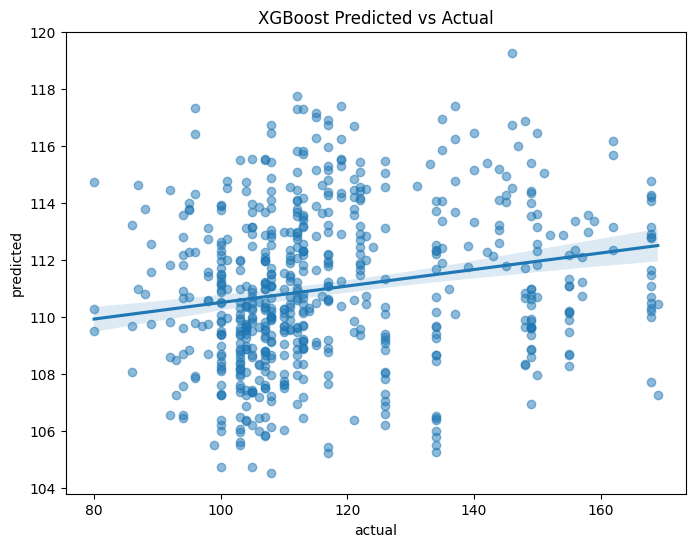

In [45]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only location

In [48]:
gwas_loc= gwas_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,Chr20_50059719,Chr20_50927742,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,1,1,0,0,0,0,0,1
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,1,0,0,1,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,0,0,1,0,0,0,1,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,1,0,0,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,0,1,0,0,0,1


In [49]:
gwas_loc_dupe= gwas_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc_dupe.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,Chr20_50059719,Chr20_50927742,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,1,1,0,0,0,0,0,1
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,1,0,0,1,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,0,0,1,0,0,0,1,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,1,0,0,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,0,0,1,0,0,0,1


In [50]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 2519 entries, Chr1_123617 to landrace
dtypes: int64(2519)
memory usage: 47.1+ MB


In [51]:
gwas_y = gwas_data.iloc[:, 2523:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


In [52]:
# Run models

In [53]:
X_train, X_test, y_train, y_test = train_test_split(gwas_loc, gwas_y, test_size=0.1, random_state=42)

In [54]:
X_train.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,Chr20_50059719,Chr20_50927742,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2674,1,0,0,0,0,0,0,1,0,0,...,0,2,0,0,1,0,0,0,1,0
s2862,0,1,2,0,0,0,1,0,0,2,...,0,0,0,0,0,1,0,0,1,0
s308,0,1,1,0,0,2,0,0,2,2,...,0,0,0,0,1,0,0,0,0,1
s202,0,0,2,0,0,0,0,0,0,2,...,0,0,0,1,0,0,0,0,1,0
s614,0,2,2,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


In [55]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [56]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

NameError: name 'bayesian_xgb_search' is not defined

In [70]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.43723367448038997), ('colsample_bytree', 0.7618817359156989), ('gamma', 0.49999999999999994), ('learning_rate', 0.04513873787214394), ('max_delta_step', 0), ('max_depth', 50), ('min_child_weight', 7), ('n_estimators', 200), ('reg_alpha', 2.7792121453370217e-08), ('reg_lambda', 1e-09), ('subsample', 0.7385163785557125)])

OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 2), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('scale_pos_weight', 0.060830282487222144), ('subsample', 0.13556548021189216)])


In [85]:
gwas_loc = gwas_loc.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7442657988351723
RMSE for dataset is:8.160008236158937& mean of this fold is 116.04897959183674
this is 7.031520884422269% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6223560516668906
RMSE for dataset is:9.487925857599015& mean of this fold is 116.33877551020409
this is 8.155428674566743% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6795257036793351
RMSE for dataset is:8.225038776698701& mean of this fold is 115.89387755102041
this is 7.09704339047398% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5990441109633038
RMSE for dataset is:8.699377286286618& mean of this fold is 115.89387755102041
this is 7.506330334367195% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6607514200266879
RMSE for datase

In [86]:
pickle.dump(best_xgbr_model, open("gwas_top1_onlyloc_xgbr_md.pickle.dat", "wb"))

In [57]:
best_xgbr_model = pickle.load(open("../pickle_bestmodels/gwas_top1_onlyloc_xgbr_md.pickle.dat", "rb"))

<Figure size 2000x2000 with 0 Axes>

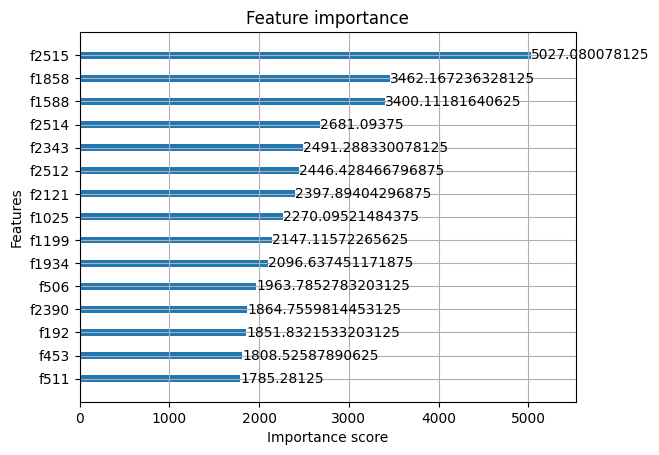

In [87]:
from xgboost import plot_importance
from matplotlib import pyplot
#best_model = pickle.load(open("Oil_kfold_10_tt_from_all.pickle.dat", "rb"))
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

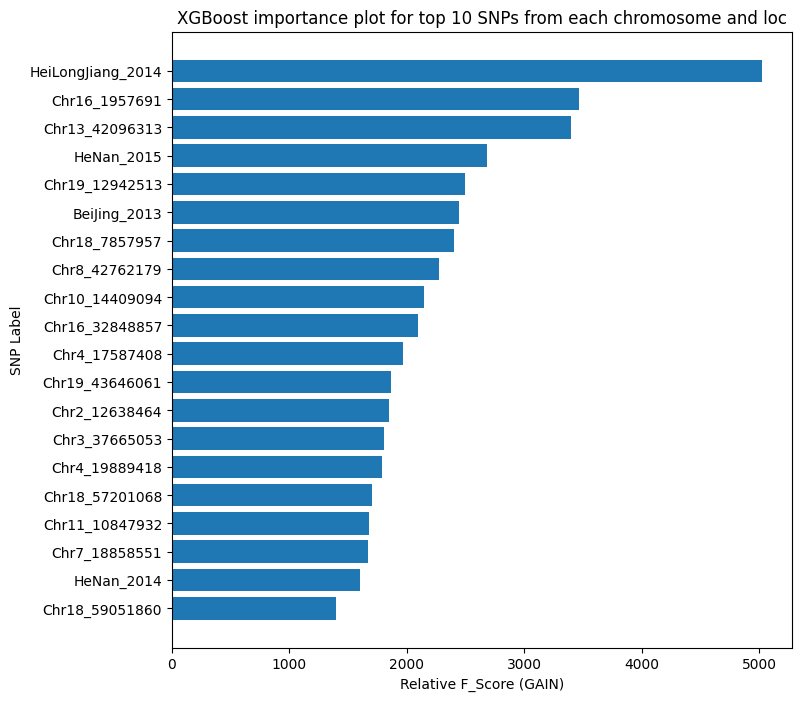

In [88]:
f_names = ['f' + str(i) for i in range(len(gwas_loc_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[gwas_loc_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome and loc')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome and loc.png')

In [89]:
explainer = shap.Explainer(best_xgbr_model)

In [90]:
shap_values = explainer(gwas_loc_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

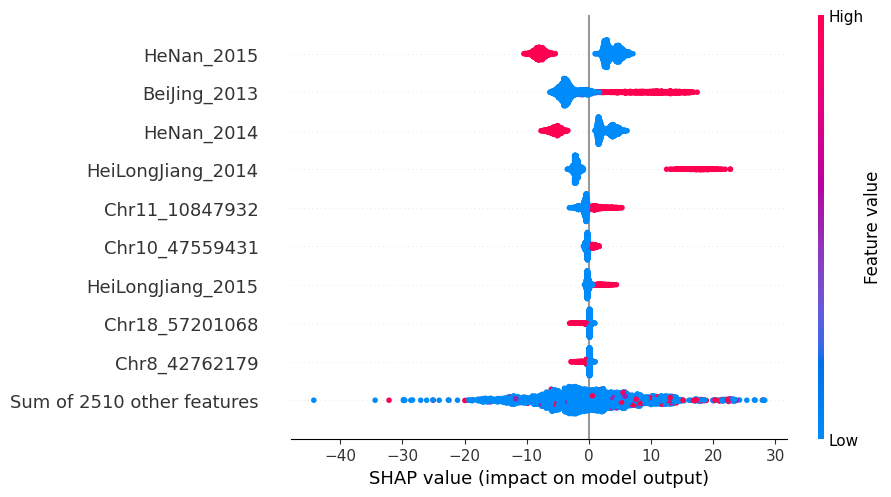

In [91]:
shap.plots.beeswarm(shap_values, show=False)

In [69]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [70]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [58]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [59]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [60]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [61]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 2519 entries, Chr1_123617 to landrace
dtypes: int64(2519)
memory usage: 11.8+ MB


In [62]:
X_holdout.head()

,Chr1_123617,Chr1_325800,Chr1_1127979,Chr1_1454789,Chr1_1721307,Chr1_2489311,Chr1_2543095,Chr1_3224401,Chr1_3642923,Chr1_3858802,...,Chr20_50059719,Chr20_50927742,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,0,2,0,0,0,0,1,0,2,...,0,0,1,0,1,0,0,0,0,1
s1014,0,0,0,0,1,0,1,1,0,2,...,0,0,0,1,0,0,0,0,0,1
s1019,0,1,0,0,0,0,1,1,0,1,...,2,0,1,0,1,0,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,0,0,1,1,0,0,0,0,0,1
s101,0,2,2,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,1,0,1


In [63]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.74
RMSE of Holdout: 9.86
Mean of Holdout: 117.42
This is 8.40% of the mean pheno data
0 117.0 107.05072
1 148.0 152.7928
2 117.0 117.66855
3 121.0 127.50224
4 119.0 126.81291


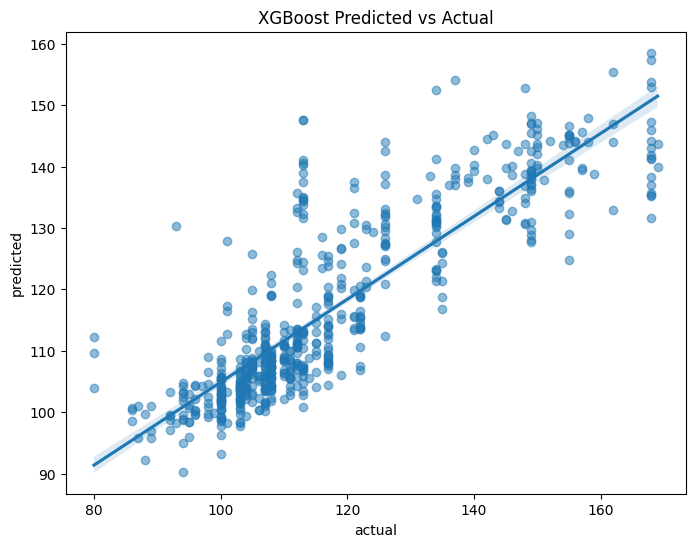

In [64]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [101]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 32), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 2), ('min_samples_split', 20), ('n_estimators', 411)])


In [2]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 32), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 2), ('min_samples_split', 20), ('n_estimators', 411)])

In [107]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.398025071528295
RMSE for dataset is:15.263730367298614& mean of this fold is 114.02857142857142
this is 13.385882306576082% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.933286424366315
RMSE for dataset is:16.592082102805538& mean of this fold is 117.57551020408164
this is 14.1118520974358% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.386989495786109
RMSE for dataset is:16.328612525782763& mean of this fold is 117.27755102040817
this is 13.92305039089819% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.023239059152774
RMSE for dataset is:15.088418176502152& mean of this fold is 114.36734693877551
this is 13.192942374172118% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -12.43846291044776
RMSE fo

In [108]:
pickle.dump(best_rfr_model, open("gwas_top1_onlyloc_rfr_md.pickle.dat", "wb"))

In [65]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/gwas_top1_onlyloc_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.23
RMSE of Holdout: 16.96
Mean of Holdout: 117.42
This is 14.45% of the mean pheno data
0 117.0 119.9491072750725
1 148.0 120.7396370887076
2 117.0 112.83189755938831
3 121.0 123.61361547415753
4 119.0 121.98198170020522


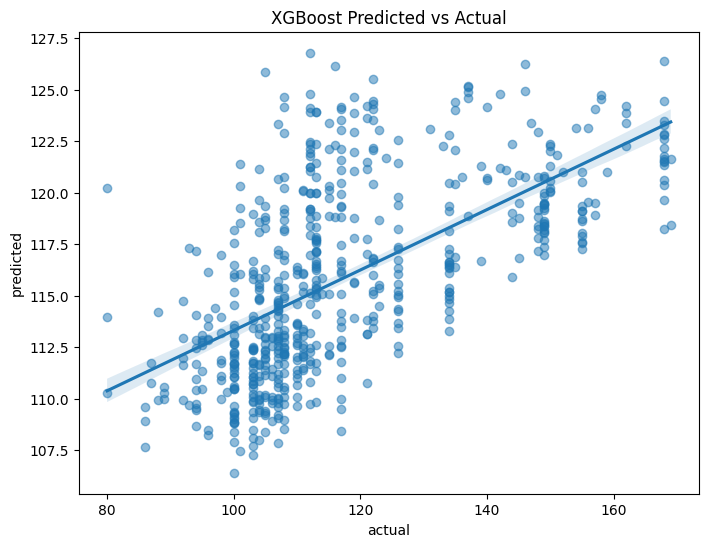

In [66]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [65]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [66]:
gwas_loc = gwas_loc.to_numpy()
gwas_y = gwas_y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7426937460694195
RMSE for dataset is:8.96080477843415& mean of this fold is 115.16734693877551
this is 7.780681778836004% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6749753963412135
RMSE for dataset is:10.235226788494437& mean of this fold is 116.83265306122449
this is 8.7605874901521% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7680596146071177
RMSE for dataset is:8.9830987445955& mean of this fold is 115.15510204081633
this is 7.8008690760496835% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7296454100588712
RMSE for dataset is:9.605543253883303& mean of this fold is 115.79591836734694
this is 8.295234745158297% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7453790797181501
RMSE for dataset 

In [67]:
pickle.dump(best_svr_model, open("gwas_top1_onlyloc_svr_md.pickle.dat", "wb"))

In [67]:
best_svr_model = pickle.load(open("../pickle_bestmodels/gwas_top1_onlyloc_svr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.74
RMSE of Holdout: 9.95
Mean of Holdout: 117.42
This is 8.47% of the mean pheno data
0 117.0 121.49981000242705
1 148.0 136.77531306229517
2 117.0 114.4997926573464
3 121.0 127.50052256503092
4 119.0 129.5004615520853


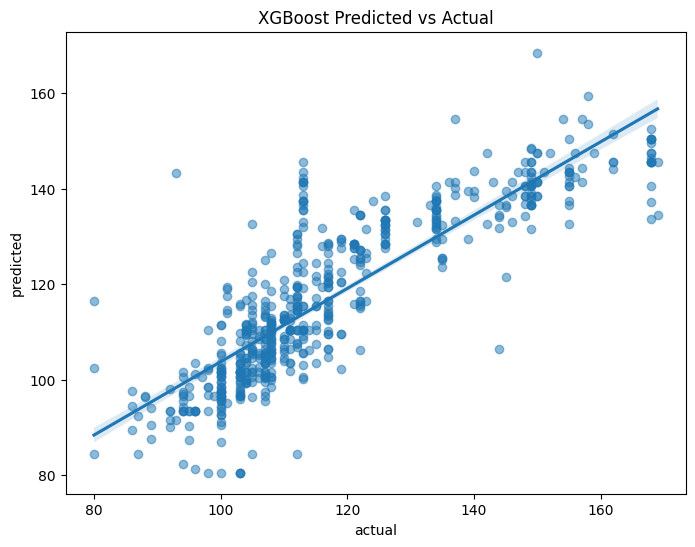

In [68]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)